# **Assignment Overview:**

In this advanced deep learning assignment, students will select a neural network architecture to solve a task such as image classification, object detection, or semantic segmentation. Students will have the freedom to choose from convolutional models, fully connected models, or recurrent neural networks (RNNs). They can fine-tune a pre-trained model, perform transfer learning, or train a model from scratch. This assignment will emphasize the use of **PyTorch Lightning** for training, **TensorBoard** or **Weights & Biases** for reporting, and **Optuna** for hyperparameter tuning. Students will evaluate their model’s performance on a test dataset and report key metrics such as accuracy, precision, recall, and F1-score.

---

### **Part 1: Data Selection and Preprocessing**

**Objective:** Select and preprocess the dataset for your chosen task.

- **Task 1:** Choose a dataset suitable for the task you are solving (e.g., CIFAR-10 for image classification, COCO for object detection, or Cityscapes for semantic segmentation).
- **Task 2:** Preprocess the data using techniques such as resizing, normalization, augmentation (if applicable), and batching.
  
   **Example for Preprocessing with PyTorch:**
   ```python
   from torchvision import datasets, transforms

   transform = transforms.Compose([
       transforms.Resize((128, 128)),
       transforms.ToTensor(),
       transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
   ])
   
   train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
   train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
   ```

**Questions to include:**
- What data preprocessing techniques are essential for your chosen task?
- How do these preprocessing steps affect model training and performance?

---

### **Part 2: Model Selection and Implementation**

**Objective:** Choose and implement a deep learning model using **PyTorch Lightning**.

- **Task 1:** Choose a model architecture that fits the task (e.g., ResNet, U-Net, RNN, etc.). You may either fine-tune a pre-trained model or build one from scratch.
- **Task 2:** Implement the model using **PyTorch Lightning**.

   **Example for Using Pre-trained ResNet for Transfer Learning:**
   ```python
   import pytorch_lightning as pl
   import torch
   import torch.nn as nn
   import torchvision.models as models

   class TransferLearningModel(pl.LightningModule):
       def __init__(self, num_classes):
           super().__init__()
           self.model = models.resnet18(pretrained=True)
           self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

       def forward(self, x):
           return self.model(x)

       def training_step(self, batch, batch_idx):
           images, labels = batch
           outputs = self.forward(images)
           loss = nn.CrossEntropyLoss()(outputs, labels)
           return loss

       def configure_optimizers(self):
           return torch.optim.Adam(self.parameters(), lr=1e-4)
   ```

**Questions to include:**
- Why did you choose this model for your task?
- What adjustments did you make to fine-tune the pre-trained model or to design your architecture from scratch?

---

### **Part 3: Model Training and Reporting**

**Objective:** Train the model and monitor its performance using **TensorBoard** or **Weights & Biases**.

- **Task 1:** Train the model using **PyTorch Lightning**. Provide clear documentation of the training loop and explain how PyTorch Lightning simplifies the process.
- **Task 2:** Use **TensorBoard** or **Weights & Biases** to track metrics such as loss, accuracy, precision, recall, and F1-score. Provide visualizations of the training process.

   **Example for Using TensorBoard in PyTorch Lightning:**
   ```python
   from pytorch_lightning.loggers import TensorBoardLogger

   logger = TensorBoardLogger("tb_logs", name="my_model")

   trainer = pl.Trainer(logger=logger, max_epochs=10)
   model = TransferLearningModel(num_classes=10)
   trainer.fit(model, train_loader)
   ```

**Questions to include:**
- How do you ensure your model does not overfit during training?
- What insights do you gain from the visualizations provided by TensorBoard or Weights & Biases?

---

### **Part 4: Hyperparameter Tuning with Optuna**

**Objective:** Optimize model hyperparameters using **Optuna**.

- **Task 1:** Set up an **Optuna** study to perform hyperparameter search on parameters like learning rate, batch size, or optimizer type.
- **Task 2:** Use the results from **Optuna** to choose the best hyperparameter configuration and retrain the model.

   **Example for Using Optuna with PyTorch Lightning:**
   ```python
   import optuna
   from optuna.integration import PyTorchLightningPruningCallback

   def objective(trial):
       model = TransferLearningModel(num_classes=10)
       trainer = pl.Trainer(max_epochs=10, callbacks=[PyTorchLightningPruningCallback(trial, monitor="val_loss")])
       trainer.fit(model, train_loader)
       return trainer.callback_metrics["val_loss"]

   study = optuna.create_study(direction="minimize")
   study.optimize(objective, n_trials=100)
   ```

**Questions to include:**
- How do different hyperparameters impact model performance?
- What were the most important hyperparameters in improving your model?

---

### **Part 5: Evaluation on Test Data**

**Objective:** Evaluate the final model on the test dataset and report key metrics.

- **Task 1:** After training and fine-tuning, evaluate your model on a separate test dataset.
- **Task 2:** Compute and report metrics such as accuracy, precision, recall, and F1-score using **scikit-learn** or **PyTorch Lightning**'s built-in tools.
  
   **Example for Evaluating Metrics:**
   ```python
   from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

   # Compute metrics
   accuracy = accuracy_score(y_true, y_pred)
   precision = precision_score(y_true, y_pred, average='macro')
   recall = recall_score(y_true, y_pred, average='macro')
   f1 = f1_score(y_true, y_pred, average='macro')

   print(f"Accuracy: {accuracy}, Precision: {precision}, Recall: {recall}, F1-Score: {f1}")
   ```

**Questions to include:**
- How does your model perform on the test dataset compared to the validation dataset?
- What strategies did you use to ensure the model generalizes well to unseen data?

---

### **Part 6: Reflection and Future Improvements**

**Objective:** Reflect on the challenges faced during model development and suggest improvements.

- **Task 1:** Reflect on the training process, challenges faced, and key takeaways from the assignment.
- **Task 2:** Suggest potential future improvements, such as using a different architecture, adding more data, or using advanced techniques like ensemble learning.

**Questions to include:**
- What were the main challenges you faced in training your model?
- How would you improve the model or experiment with different techniques in future work?

---
### **Submission Instructions:**

- Share GoogleColabs notebook privately with `keshav.s.bhandari@gmail.com` with well-documented code, including comments and explanations for each step.
- Include a PDF report that explains your approach, results, and answers to the questions.
- Provide shared-link to GoogleColabs notebook in comments sections.
- Make sure your code is reproducible and your dataset preprocessing steps are clear.
- Ensure that you include metrics, visualizations, and model insights from **TensorBoard** or **Weights & Biases**.
- Include the results of the **Optuna** hyperparameter search in your report.

---

### **Rubric:**

- **Data Preprocessing (15%):** Proper data handling and preprocessing for the chosen task.
- **Model Selection & Implementation (20%):** Clear justification for model choice and correct implementation with PyTorch Lightning.
- **Model Training & Reporting (20%):** Effective use of reporting tools (TensorBoard or Weights & Biases) and appropriate visualizations.
- **Hyperparameter Tuning (20%):** Successful implementation of Optuna for hyperparameter optimization.
- **Model Evaluation (15%):** Comprehensive evaluation of the model on test data with proper metrics.
- **Reflection (10%):** Insightful reflection on challenges and future improvements.

---

### Solution

- Step 1: Data selection and Preprocessing -
- Step 2: Model Model Selection & Implementation
- Step 3: Model Training
- Step 4: Reporting
- Step 5: Hyperparameter Tuning
- Step 6: Model Evaluation
- Step 7: Reflection

In [2]:
!pip install datasets

In [3]:
!pip install torch torchvision pytorch-lightning transformers datasets optuna wandb scikit-learn -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 39.1 MB/s eta 0:00:00


### Data Selection and preprocessing
Download GoEmotions Dataset. This is a multi-label emotion classification dataset to use for sentiment analysis. We map the 27 emotions to sentiment polarity.
This dataset contains over 58,000 Reddit comments (from diverse subreddits) annotated with 27 fine-grained emotions plus a neutral label.

In [4]:
# Data Collection

from datasets import load_dataset

dataset = load_dataset('google-research-datasets/go_emotions', 'raw')
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

raw/train-00000-of-00001.parquet:   0%|          | 0.00/24.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/211225 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
        num_rows: 211225
    })
})


## Exploring the Dataset

In [5]:
# First, let's see what columns are actually in the dataset
print("Dataset keys:")
print(dataset['train'].features)
print("\nColumn names:")
print(dataset['train'].column_names)

# Check a sample
print("\nSample data:")
print(dataset['train'][0])

Dataset keys:
{'text': Value('string'), 'id': Value('string'), 'author': Value('string'), 'subreddit': Value('string'), 'link_id': Value('string'), 'parent_id': Value('string'), 'created_utc': Value('float32'), 'rater_id': Value('int32'), 'example_very_unclear': Value('bool'), 'admiration': Value('int32'), 'amusement': Value('int32'), 'anger': Value('int32'), 'annoyance': Value('int32'), 'approval': Value('int32'), 'caring': Value('int32'), 'confusion': Value('int32'), 'curiosity': Value('int32'), 'desire': Value('int32'), 'disappointment': Value('int32'), 'disapproval': Value('int32'), 'disgust': Value('int32'), 'embarrassment': Value('int32'), 'excitement': Value('int32'), 'fear': Value('int32'), 'gratitude': Value('int32'), 'grief': Value('int32'), 'joy': Value('int32'), 'love': Value('int32'), 'nervousness': Value('int32'), 'optimism': Value('int32'), 'pride': Value('int32'), 'realization': Value('int32'), 'relief': Value('int32'), 'remorse': Value('int32'), 'sadness': Value('int32

In [6]:
emotion_columns = [col for col in dataset['train'].column_names
                   if col not in ['text', 'id', 'author', 'subreddit', 'link_id',
                                  'parent_id', 'created_utc', 'rater_id', 'example_very_unclear']]

print(f"Number of emotion columns: {len(emotion_columns)}")
print(f"Emotions: {emotion_columns}")

# Update EMOTIONS list
EMOTIONS = emotion_columns
print(f"\nUpdated EMOTIONS list with {len(EMOTIONS)} emotions")

Number of emotion columns: 28
Emotions: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']

Updated EMOTIONS list with 28 emotions


In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
import numpy as np

# Define all 27 emotions
EMOTIONS = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
    'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
    'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
    'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
    'relief', 'remorse', 'sadness', 'surprise', 'neutral'
]

print(f"Total emotions: {len(EMOTIONS)}")  # Should print 28

class GoEmotionsDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = str(item['text'])

        # Create multi-label vector (28 emotions) - FIXED
        labels = []
        for emotion in EMOTIONS:
            labels.append(float(item[emotion]))
        labels = torch.tensor(labels, dtype=torch.float)

        # Tokenization
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': labels
        }

Total emotions: 28


In [8]:
# Check available splits
print("Available splits in dataset:")
print(dataset.keys())
print("\nDataset structure:")
print(dataset)

print(f"Total emotions: {len(EMOTIONS)}")  # Should be 27


Available splits in dataset:
dict_keys(['train'])

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
        num_rows: 211225
    })
})
Total emotions: 28


In [9]:
def preprocess_goemotions():
    # Initialize tokenizer
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    # Check what splits we have
    available_splits = list(dataset.keys())
    print(f"Available splits: {available_splits}")

    # Get train data
    full_train_data = dataset['train']

    # Create validation split (85/15)
    print("Creating validation split from training data...")
    train_size = int(0.85 * len(full_train_data))
    indices = list(range(len(full_train_data)))

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_data = full_train_data.select(train_indices)
    val_data = full_train_data.select(val_indices)

    # Create test split from validation (50/50)
    print("Creating test split from validation data...")
    val_size = len(val_data) // 2
    val_indices_list = list(range(len(val_data)))

    new_val_indices = val_indices_list[:val_size]
    test_indices = val_indices_list[val_size:]

    new_val_data = val_data.select(new_val_indices)
    test_data = val_data.select(test_indices)
    val_data = new_val_data

    print(f"\nFinal split sizes:")
    print(f"Train: {len(train_data)}")
    print(f"Validation: {len(val_data)}")
    print(f"Test: {len(test_data)}")

    # Create datasets
    train_dataset = GoEmotionsDataset(train_data, tokenizer)
    val_dataset = GoEmotionsDataset(val_data, tokenizer)
    test_dataset = GoEmotionsDataset(test_data, tokenizer)

    # Create dataloaders - REDUCED num_workers to avoid multiprocessing issues
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

    return train_loader, val_loader, test_loader, tokenizer

# Execute
train_loader, val_loader, test_loader, tokenizer = preprocess_goemotions()

print(f"\n✓ Training batches: {len(train_loader)}")
print(f"✓ Validation batches: {len(val_loader)}")
print(f"✓ Test batches: {len(test_loader)}")

# Test a batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"Input IDs: {batch['input_ids'].shape}")
print(f"Attention mask: {batch['attention_mask'].shape}")
print(f"Labels: {batch['labels'].shape}")  # Should be [32, 27]
print(f"\nSample label vector: {batch['labels'][0]}")
print(f"Number of active emotions in first sample: {batch['labels'][0].sum().item()}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 659ba964-1267-4e0b-84d2-6e992ead7df8)')' thrown while requesting GET https://huggingface.co/bert-base-uncased/resolve/main/tokenizer.json
Retrying in 1s [Retry 1/5].


tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Available splits: ['train']
Creating validation split from training data...
Creating test split from validation data...

Final split sizes:
Train: 179541
Validation: 15842
Test: 15842

✓ Training batches: 5611
✓ Validation batches: 496
✓ Test batches: 496

Batch shapes:
Input IDs: torch.Size([32, 128])
Attention mask: torch.Size([32, 128])
Labels: torch.Size([32, 28])

Sample label vector: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
Number of active emotions in first sample: 1.0


## Text length analysis

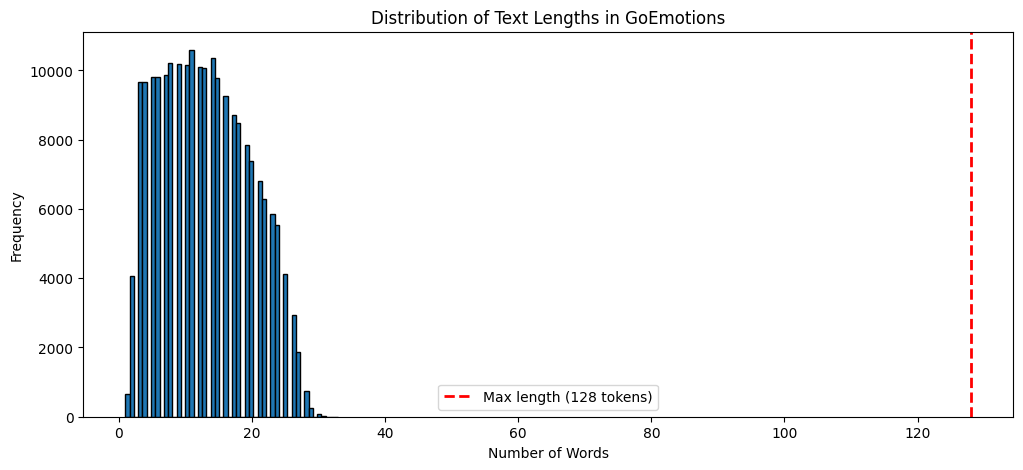

Average length: 13.00 words
Median length: 13 words
95th percentile: 24 words
Max length: 33 words


In [10]:
import matplotlib.pyplot as plt

# Analyze text lengths to determine optimal max_length
text_lengths = [len(text.split()) for text in dataset['train']['text']]

plt.figure(figsize=(12, 5))
plt.hist(text_lengths, bins=50, edgecolor='black')
plt.axvline(x=128, color='r', linestyle='--', label='Max length (128 tokens)', linewidth=2)
plt.title('Distribution of Text Lengths in GoEmotions')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Average length: {sum(text_lengths)/len(text_lengths):.2f} words")
print(f"Median length: {sorted(text_lengths)[len(text_lengths)//2]} words")
print(f"95th percentile: {sorted(text_lengths)[int(len(text_lengths)*0.95)]} words")
print(f"Max length: {max(text_lengths)} words")

## MODEL IMPLEMENTATION

In [11]:
!pip install pytorch_lightning

In [12]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
from transformers import BertModel
from torchmetrics import Accuracy, Precision, Recall, F1Score

class SentimentClassifier(pl.LightningModule):
    def __init__(self, n_classes=28, learning_rate=2e-5, dropout=0.3):
        super().__init__()
        self.save_hyperparameters()

        # Load pre-trained BERT
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # Dropout layer
        self.dropout = nn.Dropout(dropout)

        # Classification head for multi-label (28 emotions)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

        # Loss function for multi-label classification
        self.criterion = nn.BCEWithLogitsLoss()

        # Metrics (using threshold of 0.5)
        self.train_accuracy = Accuracy(task='multilabel', num_labels=n_classes, threshold=0.5)
        self.val_accuracy = Accuracy(task='multilabel', num_labels=n_classes, threshold=0.5)
        self.test_accuracy = Accuracy(task='multilabel', num_labels=n_classes, threshold=0.5)

    def forward(self, input_ids, attention_mask):
        # Get BERT output
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use [CLS] token representation
        pooled_output = outputs.pooler_output

        # Apply dropout
        output = self.dropout(pooled_output)

        # Classification
        logits = self.classifier(output)

        return logits

    def training_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        # Forward pass
        logits = self(input_ids, attention_mask)

        # Calculate loss
        loss = self.criterion(logits, labels)

        # Calculate accuracy
        preds = torch.sigmoid(logits)
        acc = self.train_accuracy(preds, labels.int())

        # Log metrics
        self.log('train_loss', loss, prog_bar=True, on_step=True, on_epoch=True)
        self.log('train_acc', acc, prog_bar=True, on_step=False, on_epoch=True)

        return loss

    def validation_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        # Forward pass
        logits = self(input_ids, attention_mask)

        # Calculate loss
        loss = self.criterion(logits, labels)

        # Calculate accuracy
        preds = torch.sigmoid(logits)
        acc = self.val_accuracy(preds, labels.int())

        # Log metrics
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_acc', acc, prog_bar=True, on_step=False, on_epoch=True)

        return loss

    def test_step(self, batch, batch_idx):
        input_ids = batch['input_ids']
        attention_mask = batch['attention_mask']
        labels = batch['labels']

        # Forward pass
        logits = self(input_ids, attention_mask)

        # Calculate loss
        loss = self.criterion(logits, labels)

        # Calculate accuracy
        preds = torch.sigmoid(logits)
        acc = self.test_accuracy(preds, labels.int())

        # Log metrics
        self.log('test_loss', loss, on_step=False, on_epoch=True)
        self.log('test_acc', acc, on_step=False, on_epoch=True)

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.learning_rate)

        # Learning rate scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,
            patience=2 # Removed verbose=True
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss'
            }
        }

# Initialize model
model = SentimentClassifier(n_classes=28, learning_rate=2e-5, dropout=0.3)

print("Model initialized!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Model initialized!
Total parameters: 109,503,772
Trainable parameters: 109,503,772


# Testing the model

In [13]:
# Test with one batch
batch = next(iter(train_loader))
logits = model(batch['input_ids'], batch['attention_mask'])

print(f"\nModel output shape: {logits.shape}")  # Should be [32, 28]
print(f"Sample logits (first 5 emotions): {logits[0][:5]}")

# Convert to probabilities
probs = torch.sigmoid(logits)
print(f"\nSample probabilities (first 5 emotions): {probs[0][:5]}")

# Get predictions (threshold = 0.5)
predictions = (probs > 0.5).int()
print(f"\nSample predictions (first 10 emotions): {predictions[0][:10]}")
print(f"Actual labels (first 10 emotions): {batch['labels'][0][:10].int()}")


Model output shape: torch.Size([32, 28])
Sample logits (first 5 emotions): tensor([ 0.0084, -0.0255, -0.4656, -0.2012, -0.1094], grad_fn=<SliceBackward0>)

Sample probabilities (first 5 emotions): tensor([0.5021, 0.4936, 0.3857, 0.4499, 0.4727], grad_fn=<SliceBackward0>)

Sample predictions (first 10 emotions): tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32)
Actual labels (first 10 emotions): tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=torch.int32)


### Model Training with Weights and Biases

In [14]:
# Install W&B
!pip install wandb

# Login to W&B
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aakritidh208 (aakritidh208-texas-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Setting up W&B logger

> Add blockquote



In [15]:
from pytorch_lightning.loggers import WandbLogger
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor

# Initialize W&B logger
wandb_logger = WandbLogger(
    project='goemotions-sentiment-analysis',
    name='bert-multilabel-baseline',
    log_model=True
)

# Log hyperparameters
wandb_logger.experiment.config.update({
    "model": "bert-base-uncased",
    "task": "multi-label classification",
    "num_emotions": 28,
    "learning_rate": 2e-5,
    "batch_size": 32,
    "max_length": 128,
    "dropout": 0.3
})

### Setup callbacks

In [16]:
# Model checkpoint - saves best model
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath='checkpoints/',
    filename='goemotions-{epoch:02d}-{val_loss:.2f}',
    save_top_k=3,
    mode='min'
)

# Early stopping - stops training if no improvement
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=True,)

### Hyperparameter Tuning with Optuna

In [17]:
# Install Optuna
!pip install optuna
!pip install optuna-integration[pytorch_lightning]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 827.9/827.9 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 4.1 MB/s eta 0:00:00


In [18]:
!pip install -U optuna pytorch-lightning

In [19]:
!pip install optuna

In [20]:
# def objective(trial):
#     # Suggest hyperparameters
#     learning_rate = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
#     dropout = trial.suggest_float('dropout', 0.1, 0.5)
#     batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

#     # Recreate dataloaders with new batch size
#     # train_loader_optuna = DataLoader(
#     #     GoEmotionsDataset(dataset['train'].select(range(int(0.85 * len(dataset['train'])))), tokenizer),
#     #     batch_size=batch_size,
#     #     shuffle=True,
#     #     num_workers=0
#     # )

#     # val_loader_optuna = DataLoader(
#     #     GoEmotionsDataset(dataset['train'].select(range(int(0.85 * len(dataset['train'])), len(dataset['train']))), tokenizer),
#     #     batch_size=batch_size,
#     #     shuffle=False,
#     #     num_workers=0
#     # )

#     train_subset = dataset['train'].shuffle(seed=42).select(range(2000))
#     val_subset = dataset['train'].shuffle(seed=43).select(range(500))


#     train_loader_optuna = DataLoader(
#     GoEmotionsDataset(train_subset, tokenizer),
#     batch_size=batch_size,
#     shuffle=True
#     )
#     val_loader_optuna = DataLoader(
#     GoEmotionsDataset(val_subset, tokenizer),
#     batch_size=batch_size,
#     shuffle=False
#     )


#     # Initialize model
#     model = SentimentClassifier(
#         n_classes=28,
#         learning_rate=learning_rate,
#         dropout=dropout
#     )

#     # Trainer for hyperparameter search (without pruning callback)
#     trainer = pl.Trainer(
#         max_epochs=3,
#         accelerator='gpu' if torch.cuda.is_available() else 'cpu',
#         devices=1,
#         logger=False,
#         enable_checkpointing=False,
#         callbacks=[],  # Empty callbacks list
#         enable_progress_bar=False
#     )

#     # Train
#     trainer.fit(model, train_loader_optuna, val_loader_optuna)

#     # Return validation loss
#     return trainer.callback_metrics["val_loss"].item()


def objective(trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 5e-5, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    # ✅ Use a smaller subset of data for faster trials
    train_subset = dataset['train'].shuffle(seed=42).select(range(2000))
    val_subset = dataset['train'].shuffle(seed=43).select(range(500))

    # ✅ Reuse pre-tokenized data if possible (saves tons of time)
    train_loader_optuna = DataLoader(
        GoEmotionsDataset(train_subset, tokenizer),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    val_loader_optuna = DataLoader(
        GoEmotionsDataset(val_subset, tokenizer),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    # Initialize model with hyperparameters from the current trial
    model = SentimentClassifier(
        n_classes=28,
        learning_rate=learning_rate,
        dropout=dropout
    )

    # ✅ Add Optuna pruning callback
    from pytorch_lightning.callbacks import EarlyStopping
    from optuna.integration import PyTorchLightningPruningCallback


    # ✅ Use only 1 epoch for fast search
    trainer = pl.Trainer(
        max_epochs=1,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=False,
        callbacks=[]
    )

    # Train and validate
    trainer.fit(model, train_loader_optuna, val_loader_optuna)

    # Return validation loss for Optuna to minimize
    val_loss = trainer.callback_metrics.get("val_loss")
    if val_loss is None:
        return float('inf')  # handle missing metric safely
    return val_loss.item()

## Run Optuna Study

In [21]:
import optuna

# Create study
study = optuna.create_study(
    direction='minimize',
    study_name='goemotions-hyperparam-search',
    pruner=optuna.pruners.MedianPruner()
)

# Run optimization
print("Starting hyperparameter search...")
study.optimize(objective, n_trials=3, timeout=1000)  # 10 trials or 1 hour

# Print results
print("\n" + "="*50)
print("BEST HYPERPARAMETERS")
print("="*50)
print(f"Best trial: {study.best_trial.number}")
print(f"Best validation loss: {study.best_trial.value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# best_params = study.best_trial.params
# print(best_params)

[I 2025-11-08 17:05:04,863] A new study created in memory with name: goemotions-hyperparam-search


Starting hyperparameter search...


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | bert           | BertModel          | 109 M  | eval 
1 | dropout        | Dropout            | 0      | train
2 | classifier     | Linear             | 21.5 K | train
3 | criterion      | BCEWithLogitsLoss  | 0      | train
4 | train_accuracy | MultilabelAccuracy | 0      | train
5 | val_accuracy   | MultilabelAccuracy | 0      | train
6 | test_accuracy  | MultilabelAccuracy | 0      | train
--------------------------------------------------------------
109 M     Trainable params
0 


BEST HYPERPARAMETERS
Best trial: 1
Best validation loss: 0.1820

Best hyperparameters:
  learning_rate: 4.146235044444236e-05
  dropout: 0.4689407660860111
  batch_size: 32


In [22]:
best_params = study.best_params
print(best_params)

{'learning_rate': 4.146235044444236e-05, 'dropout': 0.4689407660860111, 'batch_size': 32}


In [23]:
best_batch_size = best_params['batch_size']

train_loader_final = DataLoader(
    GoEmotionsDataset(dataset['train'].select(range(int(0.85 * len(dataset['train'])))), tokenizer),
    batch_size=best_batch_size,
    shuffle=True,
    num_workers=0
)

val_loader_final = DataLoader(
    GoEmotionsDataset(dataset['train'].select(range(int(0.85 * len(dataset['train'])), len(dataset['train']))), tokenizer),
    batch_size=best_batch_size,
    shuffle=False,
    num_workers=0
)


In [24]:
model_final = SentimentClassifier(
    n_classes=28,
    learning_rate=best_params['learning_rate'],
    dropout=best_params['dropout']
)


In [26]:
trainer = pl.Trainer(
    max_epochs=5,  # or however many you want for final training
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    logger=True,
    callbacks=[checkpoint_callback, early_stop_callback],
)

trainer.fit(model_final, train_loader_final, val_loader_final)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | bert           | BertModel          | 109 M  | eval 
1 | dropout        | Dropout            | 0      | train
2 | classifier     | Linear             | 21.5 K | train
3 | criterion      | BCEWithLogitsLoss  | 0      | train
4 | train_accuracy | MultilabelAccuracy | 0      | train
5 | val_accuracy   | MultilabelAccuracy | 0      | train
6 | test_accuracy  | MultilabelAccuracy | 0      | train
--------------------------------------------------------------
109 M     Trainable params
0 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 0.113


...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.111


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 3 records. Best score: 0.111. Signaling Trainer to stop.
INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.
